# 📸 Computer Vision for Road Safety: Accident Detection System
**Framework:** TensorFlow/Keras & PyTorch (Hybrid)

### 1. Executive Summary
This project implements a Deep Learning solution to automate road incident detection using **Transfer Learning**. By leveraging the **EfficientNetV2-B0** architecture, we developed a binary classifier capable of distinguishing between 'Incident' and 'Normal' road conditions.

### 2. Technical Stack
* **Base Model:** EfficientNetV2-B0 (Pre-trained on ImageNet).
* **Optimization:** Fine-tuning with dynamic learning rates.
* **Generalization:** Advanced Keras Preprocessing layers for Data Augmentation.
* **Efficiency:** TF.Data Autotuning and Prefetching for optimized GPU throughput.

### 3. Imports & Environment Setup

In [7]:
import os
import zipfile
import collections
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetV2B0

from sklearn.metrics import confusion_matrix, classification_report


# Performance Monitoring
print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow Version: 2.21.0
GPU Available: []


### 4. Data Ingestion & Directory Mapping

In [8]:
# --- Dataset Extraction & Validation ---
ZIP_PATH = '../assets/imagens.zip'
EXTRACT_DIR = 'extracted_data'

# Cleaning previous extractions to ensure a fresh environment
if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

# Logic to handle nested folder structures often found in zip uploads
DATA_DIR = os.path.join(EXTRACT_DIR, 'imagens')

def audit_dataset(path):
    print(f"🔍 Auditing Dataset at: {path}")
    counts = collections.OrderedDict()
    for class_name in sorted(os.listdir(path)):
        class_path = os.path.join(path, class_name)
        if os.path.isdir(class_path):
            files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            counts[class_name] = len(files)
            print(f"   - Class '{class_name}': {len(files)} images")
    return counts

class_counts = audit_dataset(DATA_DIR)

PermissionError: [WinError 32] O arquivo já está sendo usado por outro processo: 'extracted_data\\imagens\\sim\\acidente de carro_674.jpg'

### 5. Dataset Pipeline (TF.Data Optimization)

In [ ]:
# --- Configuration & Pipeline Optimization ---
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
VALIDATION_SPLIT = 0.20

# Create training set
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)
# Capture class names here
dataset_class_names = train_ds_raw.class_names

# Create validation set
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=VALIDATION_SPLIT,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='binary'
)

# --- Performance Optimization ---
# Prefetching allows the CPU to prepare data while the GPU is training
train_ds = train_ds_raw.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds_raw.prefetch(buffer_size=tf.data.AUTOTUNE)

print("✅ Data pipelines optimized with AUTOTUNE prefetching.")

Found 1313 files belonging to 2 classes.
Using 1051 files for training.
Found 1313 files belonging to 2 classes.
Using 262 files for validation.
✅ Data pipelines optimized with AUTOTUNE prefetching.


We use AUTOTUNE so that the model never waits for the hard drive.

### 6. Data Augmentation & Transfer Learning

We use data augmentation because it reduces overfitting.

In [ ]:
# --- 1. Data Augmentation Model ---
# This layer is only active during training.
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15, fill_mode='reflect'),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode='reflect'),
    layers.RandomZoom(0.2, fill_mode='reflect'),
    layers.RandomBrightness(0.2),
    layers.RandomContrast(0.2),
], name="data_augmentation_layer")

# --- 2. Base Model (EfficientNetV2) ---
# EfficientNetV2-B0 is chosen for its superior efficiency and accuracy vs traditional ResNet
base_model = EfficientNetV2B0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Frozen initial state for Transfer Learning

print("🧠 Architecture: EfficientNetV2-B0 initialized with frozen ImageNet weights.")

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
🧠 Architecture: EfficientNetV2-B0 initialized with frozen ImageNet weights.


### 7. Building the Functional Model

In [ ]:
# --- Model Assembly ---
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False) # Keep base_model in inference mode during initial training
x = layers.GlobalAveragePooling2D()(x) # Reduces spatial dimensions to a feature vector
x = layers.Dropout(0.3)(x) # Regularization to prevent overfitting
outputs = layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation_layer         │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,920,593 (22.59 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

### 8. Training & Fine-Tuning Strategy

#### Two-Step Optimization:
To achieve high accuracy without destroying the pre-trained weights, we use a two-step approach:
1. **Initial Training:** Train only the top Dense layer while `base_model` is frozen.
2. **Fine-Tuning:** Unfreeze the `base_model` and retrain with a significantly lower learning rate (1e-5) to adapt the high-level features to our road safety domain.

#### 8.1 - Initial Training (Warm-up)

At this stage, we train only the "head" of the model (the layers we added). The base model remains frozen to extract generic features from ImageNet.

In [ ]:
INITIAL_EPOCHS = 10

print("Starting Phase 1: Training top layers...")
history_initial = model.fit(
    train_ds,
    epochs=INITIAL_EPOCHS,
    validation_data=val_ds
)

os.makedirs('models', exist_ok=True)

# Saving the initial weights
model.save("../models/accident_cnn_warmup.keras")
print("✅ Phase 1 complete. Initial weights saved.")

Starting Phase 1: Training top layers...
Epoch 1/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 89ms/step - accuracy: 0.7127 - loss: 0.5777 - val_accuracy: 0.7672 - val_loss: 0.5460
Epoch 2/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7003 - loss: 0.5825 - val_accuracy: 0.7824 - val_loss: 0.5339
Epoch 3/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.7203 - loss: 0.5606 - val_accuracy: 0.7901 - val_loss: 0.5223
Epoch 4/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.7345 - loss: 0.5389 - val_accuracy: 0.7977 - val_loss: 0.5114
Epoch 5/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.7326 - loss: 0.5439 - val_accuracy: 0.8130 - val_loss: 0.5019
Epoch 6/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7441 - loss: 0.5317 - val_accuracy: 0.8168 - val_loss: 0.4936
Epoch 7/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7441 - loss: 0.5326 - val_accuracy: 0.8244 - val_loss: 0.4869
Epoch 8/10
33/33 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.7602 

#### 8.2 Initial Performance Visualization

Before moving on to fine-tuning, we need to validate that the model is learning correctly.

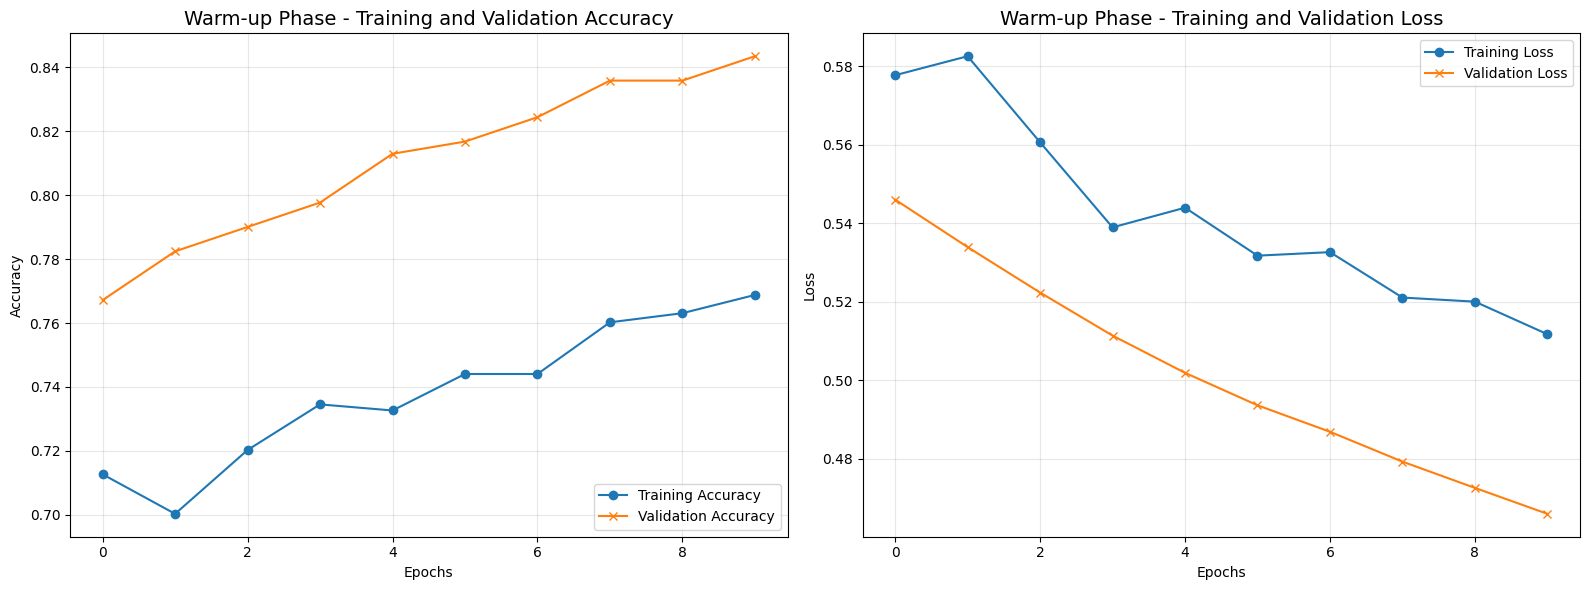

In [ ]:
def plot_training_results(history, title_prefix="Initial"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 6))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
    plt.title(f'{title_prefix} - Training and Validation Accuracy', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend(loc='lower right')
    plt.grid(True, alpha=0.3)

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', marker='o')
    plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
    plt.title(f'{title_prefix} - Training and Validation Loss', fontsize=14)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_results(history_initial, title_prefix="Warm-up Phase")

#### 8.3 Fine-Tuning

In [ ]:
base_model.trainable = True

# We use a much lower learning rate for fine-tuning to avoid catastrophic forgetting
FINE_TUNE_LR = 1e-5

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=FINE_TUNE_LR),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

FINE_TUNE_EPOCHS = 10
TOTAL_EPOCHS = INITIAL_EPOCHS + FINE_TUNE_EPOCHS

print(f"Starting Phase 2: Fine-tuning {len(model.trainable_variables)} variables...")

history_fine = model.fit(
    train_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_initial.epoch[-1],
    validation_data=val_ds
)

print("✅ Fine-tuning complete.")

🚀 Starting Phase 2: Fine-tuning 243 variables...
Epoch 10/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 63s 462ms/step - accuracy: 0.6927 - loss: 0.6081 - val_accuracy: 0.7672 - val_loss: 0.5598
Epoch 11/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 303ms/step - accuracy: 0.7288 - loss: 0.5802 - val_accuracy: 0.7595 - val_loss: 0.5599
Epoch 12/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 301ms/step - accuracy: 0.7441 - loss: 0.5704 - val_accuracy: 0.7786 - val_loss: 0.5449
Epoch 13/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 299ms/step - accuracy: 0.7517 - loss: 0.5576 - val_accuracy: 0.7901 - val_loss: 0.5279
Epoch 14/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 294ms/step - accuracy: 0.7916 - loss: 0.5342 - val_accuracy: 0.8053 - val_loss: 0.5125
Epoch 15/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 288ms/step - accuracy: 0.7831 - loss: 0.5245 - val_accuracy: 0.8053 - val_loss: 0.5020
Epoch 16/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 295ms/step - accuracy: 0.7992 - loss: 0.5013 - val_accuracy: 0.8168 - val_loss: 0.4904
Epoch 17/20
33/33 ━━━━━━━━━━━━━━━━━━━━ 10

#### 8.4 Inflection Point

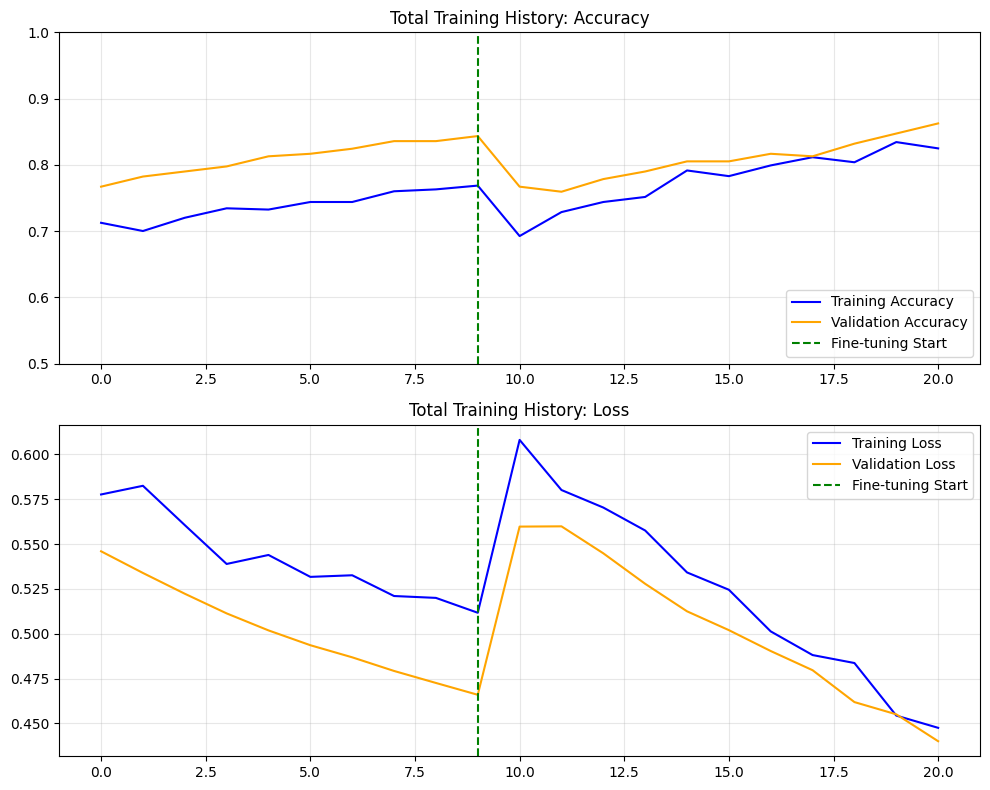

In [ ]:
# Combining metrics from both phases
acc = history_initial.history['accuracy'] + history_fine.history['accuracy']
val_acc = history_initial.history['val_accuracy'] + history_fine.history['val_accuracy']
loss = history_initial.history['loss'] + history_fine.history['loss']
val_loss = history_initial.history['val_loss'] + history_fine.history['val_loss']

plt.figure(figsize=(10, 8))

# Global Accuracy Plot
plt.subplot(2, 1, 1)
plt.plot(acc, label='Training Accuracy', color='blue')
plt.plot(val_acc, label='Validation Accuracy', color='orange')
plt.ylim([0.5, 1.0])
plt.axvline(INITIAL_EPOCHS-1, color='green', linestyle='--', label='Fine-tuning Start')
plt.title('Total Training History: Accuracy')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)

# Global Loss Plot
plt.subplot(2, 1, 2)
plt.plot(loss, label='Training Loss', color='blue')
plt.plot(val_loss, label='Validation Loss', color='orange')
plt.axvline(INITIAL_EPOCHS-1, color='green', linestyle='--', label='Fine-tuning Start')
plt.title('Total Training History: Loss')
plt.legend(loc='upper right')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 8.5 Visual Inference (Qualitative Analysis)

We will analyze the images to see where the model is going wrong.

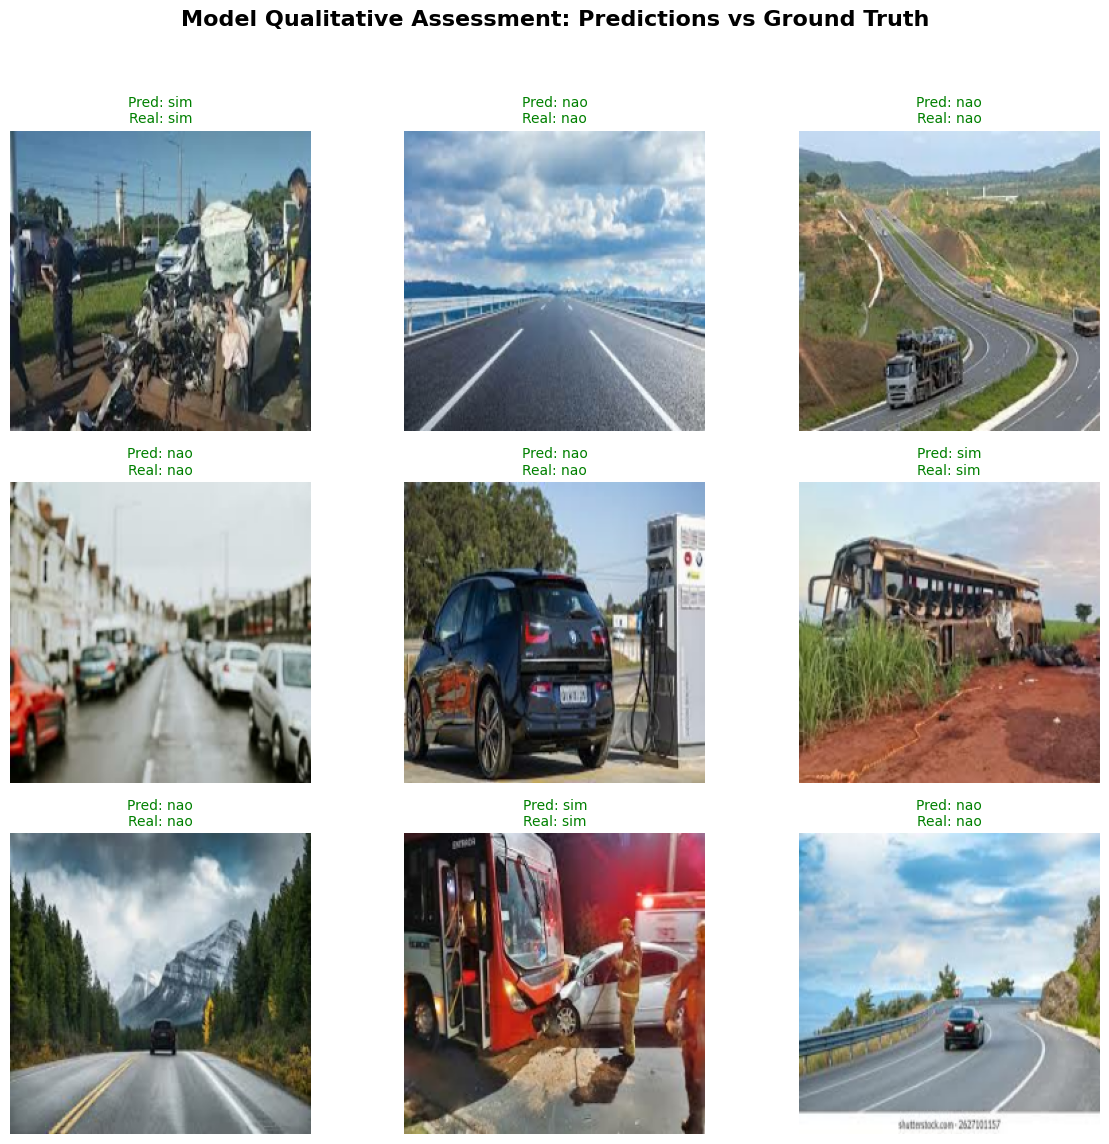

In [ ]:
# --- Visualizing Model Predictions on Real Data ---
# Retrieve a batch of validation images
image_batch, label_batch = next(val_ds.as_numpy_iterator())
predictions = model.predict_on_batch(image_batch).flatten()

# Applying threshold for binary classification
predictions = tf.where(predictions < 0.5, 0, 1).numpy()
label_batch = label_batch.flatten().astype(int)

# Mapping indices back to class names for display
# Use the 'dataset_class_names' variable captured during dataset creation
class_labels = dataset_class_names

plt.figure(figsize=(12, 12))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(image_batch[i].astype("uint8"))

    # Text Color: Green if Correct, Red if Incorrect
    color = "green" if predictions[i] == label_batch[i] else "red"

    plt.title(f"Pred: {class_labels[predictions[i]]}\nReal: {class_labels[label_batch[i]]}",
              color=color, fontsize=10)
    plt.axis("off")

plt.suptitle("Model Qualitative Assessment: Predictions vs Ground Truth", fontsize=16, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### 9. Detailed Performance Metrics

#### 9.1 (Confusion Matrix)

📊 Evaluating full validation set...

🛡️ CNN FINAL CLASSIFICATION REPORT
              precision    recall  f1-score   support

         nao       0.85      0.88      0.86       131
         sim       0.87      0.85      0.86       131

    accuracy                           0.86       262
   macro avg       0.86      0.86      0.86       262
weighted avg       0.86      0.86      0.86       262



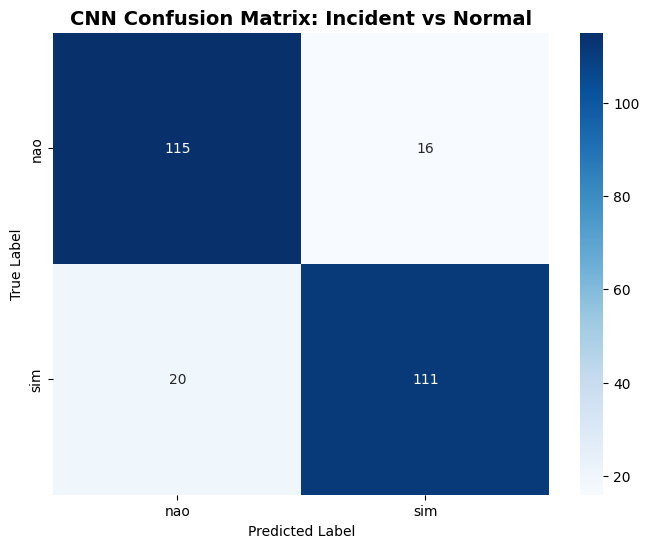

In [ ]:
# --- GENERATING DETAILED METRICS ---
all_labels = []
all_preds = []

print("📊 Evaluating full validation set...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    all_preds.extend(tf.where(preds < 0.5, 0, 1).numpy().flatten())
    all_labels.extend(labels.numpy().astype(int).flatten())

# Classification Report
print("\n" + "="*60)
print("🛡️ CNN FINAL CLASSIFICATION REPORT")
print("="*60)
print(classification_report(all_labels, all_preds, target_names=class_labels))

# Plotting the Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('CNN Confusion Matrix: Incident vs Normal', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### 10. Final Persistence & Deployment

In [ ]:
# Save the optimized final model
model.save("../models/accident_detection_final_optimized.keras")

# Export feature metadata (optional but recommended for consistency)
metadata = {
    "class_names": class_labels,
    "img_size": IMG_SIZE,
    "base_architecture": "EfficientNetV2-B0"
}
with open('../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f)

print("✅ Final optimized model and metadata exported to /models/")
print("🚀 Ready for GitHub and Streamlit deployment!")

✅ Final optimized model and metadata exported to /models/
🚀 Ready for GitHub and Streamlit deployment!
